## Deep Learning Models for Image Classification  
### Assignment 3 (CIE II)

**Name:** Arun Kumar  
**Roll No:** 23EJDAI005  
**Subject:** Deep Learning 

**Github Link:** https://github.com/Arun-0190/DeepLearning/tree/main/Project

---

### Objective
To design, implement, and evaluate deep learning models (CNN and LSTM) on a publicly available dataset using standard evaluation metrics.

### Dataset Description

* Dataset: **Intel Image Classification Dataset**

* Total Classes:

  * Buildings
  * Forest
  * Glacier
  * Mountain
  * Sea
  * Street

* Total Samples:

  * Training: ~14,000 images
  * Testing: ~3,000 images

* Key Characteristics:

  * Real-world natural scenes
  * High intra-class similarity (e.g., mountain vs glacier)
  * Multi-scale visual patterns

* Learning Objective:

  * Map image → class label
    [
    f(x) = y
    ]

* Challenge:

  * Spatial feature overlap between classes
  * Requires both **local + global feature understanding**


In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [ ]:
train_path = "Dataset/seg_train"
val_path   = "Dataset/seg_testt"

### Data Preprocessing

* Steps Applied:

  * Resize images → uniform shape
  * Convert to tensor
  * Apply augmentation

* Transformations Used:

  * Resize: ensures consistent input size
  * Horizontal Flip: improves generalization

* Tensor Representation:

  * Image shape:
    [
    (H, W, C) \rightarrow (C, H, W)
    ]

* Why preprocessing?

  * Neural networks require fixed-size input
  * Improves convergence and training stability

* Code Insight:

```python
transforms.Resize((224, 224))
```

* Reduces computation while preserving key features


In [43]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset   = datasets.ImageFolder(val_path, transform=transform)

In [44]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

In [45]:
print(train_dataset.classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Model 1: CNN + LSTM Architecture

#### CNN Component

* Extracts spatial features using convolution:
  $$
  (I * K)(x,y) = \sum I(x+i, y+j)K(i,j)
  $$

* Architecture:

  * Conv → ReLU → MaxPooling (repeated 3 times)

* Effect of pooling:
  $$
  224 \rightarrow 112 \rightarrow 56 \rightarrow 28
  $$

* Final feature map:
  $$
  (B, 128, 28, 28)
  $$

* Interpretation:

  * 128 feature channels capturing different visual patterns
  * Spatial resolution reduced for efficient learning

---

#### Sequence Conversion

```python
x = x.view(B, C, H*W)
x = x.permute(0, 2, 1)
```

* Converts 2D feature map → sequence:

  $$
  (B, 128, 28×28) \rightarrow (B, 784, 128)
  $$

* Explanation:

  * Each spatial location becomes a **time step**
  * Sequence length:
    $$
    28 \times 28 = 784
    $$

* Insight:

  * The image is treated like a sequence of feature vectors

---

#### LSTM Component

* Learns sequential dependencies:
  $$
  h_t = \sigma(Wx_t + Uh_{t-1})
  $$

* Captures:

  * Relationships between distant spatial regions
  * Contextual dependencies across the image

* Advantage:

  * Adds temporal-style learning to spatial features

---

#### Final Classification

* Uses last timestep output:

```python
x = x[:, -1, :]
```

* Applies fully connected layer:
  $$
  y = \text{Softmax}(Wx + b)
  $$

* Output:

  * Probability distribution over 6 classes

---

#### Limitations

* Converts 2D image → 1D sequence:

  * Loss of spatial structure

* Long sequence length:
  $$
  784 \text{ timesteps}
  $$

  * Increases computational cost

* LSTM is not inherently designed for spatial data:

  * Less effective than attention-based models

---

#### Key Takeaway

* CNN extracts **local spatial features**
* LSTM models **sequential relationships**
* However, global spatial understanding remains limited compared to transformer-based approaches


In [46]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=6):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            batch_first=True
        )

        # Fully connected
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)  # (B, 128, 16, 16)

        # reshape → sequence
        B, C, H, W = x.size()
        x = x.view(B, C, H*W)      # (B, 128, 256)
        x = x.permute(0, 2, 1)     # (B, 256, 128)

        # LSTM
        x, _ = self.lstm(x)

        # take last timestep
        x = x[:, -1, :]

        x = self.fc(x)
        return x

In [47]:
model = CNN_LSTM(num_classes=6).to(device)

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training Process

* Loss Function:

  * Cross Entropy:
    $$
    L = -\sum y \log(\hat{y})
    $$

* Optimizer:

  * Adam:
    $$
    \theta = \theta - \alpha \cdot \nabla L
    $$

* Training Steps:

  1. Forward pass
  2. Compute loss
  3. Backpropagation
  4. Update weights

---

#### Code Insight

```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

* Clears gradients → computes new gradients → updates weights

---

#### Accuracy Calculation

[
Accuracy = \frac{Correct\ Predictions}{Total\ Samples}
]


In [50]:
train_acc_list = []
train_loss_list = []

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(
            loss=loss.item(),
            acc=100 * correct / total
        )

    epoch_acc = 100 * correct / total
    epoch_loss = total_loss / len(train_loader)

    train_acc_list.append(epoch_acc)
    train_loss_list.append(epoch_loss)

    print(f"Epoch {epoch+1} Done | Acc: {epoch_acc:.2f}% | Loss: {epoch_loss:.4f}")

Epoch 1/10: 100%|██████████| 439/439 [01:17<00:00,  5.68it/s, acc=33.2, loss=1.39]


Epoch 1 Done | Acc: 33.21% | Loss: 1.6104


Epoch 2/10: 100%|██████████| 439/439 [00:52<00:00,  8.34it/s, acc=37.6, loss=1.12]


Epoch 2 Done | Acc: 37.57% | Loss: 1.5373


Epoch 3/10: 100%|██████████| 439/439 [01:13<00:00,  5.97it/s, acc=42.9, loss=1.86]


...

Epoch 8 Done | Acc: 64.44% | Loss: 0.9092


Epoch 9/10: 100%|██████████| 439/439 [00:52<00:00,  8.33it/s, acc=67.9, loss=0.73]


Epoch 9 Done | Acc: 67.94% | Loss: 0.8340


Epoch 10/10: 100%|██████████| 439/439 [00:52<00:00,  8.31it/s, acc=69.8, loss=0.83]

Epoch 10 Done | Acc: 69.81% | Loss: 0.7976


### Model Evaluation Metrics

* Accuracy:
  $$
  \frac{TP + TN}{Total}
  $$

* Precision:
  $$
  \frac{TP}{TP + FP}
  $$

* Recall:
  $$
  \frac{TP}{TP + FN}
  $$

* F1 Score:
  $$
  2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
  $$

---

#### Why multiple metrics?

* Accuracy alone can be misleading
* F1-score balances precision and recall


In [51]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Validation Accuracy: {100*correct/total:.2f}%")

Validation Accuracy: 71.00%


In [52]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

### Confusion Matrix Analysis

* Matrix Representation:
  $$
  C_{ij} = \text{Actual class i predicted as class j}
  $$

* Helps identify:

  * Misclassification patterns
  * Weak classes

---

#### Observation (from results)

* Confusion between:

  * Glacier ↔ Mountain
  * Sea ↔ Buildings

* Reason:

  * Similar textures and visual features


              precision    recall  f1-score   support

   buildings       0.66      0.66      0.66       437
      forest       0.94      0.87      0.90       474
     glacier       0.61      0.74      0.67       553
    mountain       0.64      0.70      0.67       525
         sea       0.73      0.52      0.61       510
      street       0.75      0.75      0.75       501

    accuracy                           0.71      3000
   macro avg       0.72      0.71      0.71      3000
weighted avg       0.72      0.71      0.71      3000



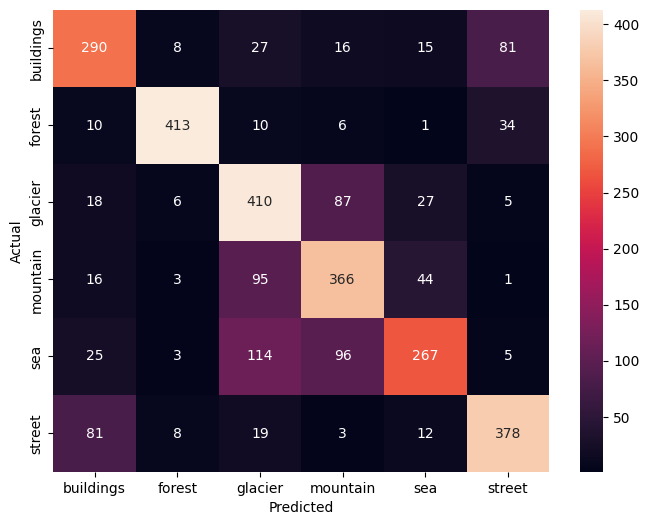

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Model 2: Vision Transformer (ViT)

#### Core Idea

* Image → patches → sequence

$$
Image → (16×16)\ patches → Tokens
$$

---

#### Self-Attention Mechanism

$$
Attention(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V
$$

* Captures global relationships
* Every patch attends to every other patch

---

#### Why ViT Works Better

* Global context awareness
* No information loss like pooling
* Learns long-range dependencies

---

#### Code Insight

```python
outputs = model_vit(images).logits
```

* Internally:

  * Patch embedding
  * Transformer encoder
  * Classification head


In [56]:
from transformers import ViTForImageClassification
model_vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=6,
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([6])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [57]:
for param in model_vit.vit.parameters():
    param.requires_grad = False

In [58]:
model_vit.to(device)
optimizer_vit = torch.optim.Adam(model_vit.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

### ViT Training Strategy

* Pretrained model used
* Backbone frozen:

```python
for param in model_vit.vit.parameters():
    param.requires_grad = False
```

---

#### Why freeze?

* Retains learned features
* Faster training
* Prevents overfitting

---

#### Fine-tuning only classifier

[
y = Wx + b
]

* Adapts model to dataset


In [59]:
from tqdm import tqdm

vit_acc_list = []
vit_loss_list = []

epochs = 5

for epoch in range(epochs):
    model_vit.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"ViT Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = model_vit(images).logits
        loss = criterion(outputs, labels)

        optimizer_vit.zero_grad()
        loss.backward()
        optimizer_vit.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100*correct/total)

    epoch_acc = 100 * correct / total
    epoch_loss = total_loss / len(train_loader)

    vit_acc_list.append(epoch_acc)
    vit_loss_list.append(epoch_loss)

    print(f"ViT Epoch {epoch+1} | Acc: {epoch_acc:.2f}% | Loss: {epoch_loss:.4f}")

ViT Epoch 1/5: 100%|██████████| 439/439 [03:08<00:00,  2.33it/s, acc=84.2, loss=0.238]


ViT Epoch 1 | Acc: 84.18% | Loss: 0.5949


ViT Epoch 2/5: 100%|██████████| 439/439 [03:07<00:00,  2.34it/s, acc=92.5, loss=0.236]


ViT Epoch 2 | Acc: 92.45% | Loss: 0.2505


ViT Epoch 3/5: 100%|██████████| 439/439 [03:00<00:00,  2.44it/s, acc=93, loss=0.299]


ViT Epoch 3 | Acc: 92.97% | Loss: 0.2124


ViT Epoch 4/5: 100%|██████████| 439/439 [03:00<00:00,  2.43it/s, acc=93.4, loss=0.179]


ViT Epoch 4 | Acc: 93.42% | Loss: 0.1959


ViT Epoch 5/5: 100%|██████████| 439/439 [02:59<00:00,  2.44it/s, acc=93.6, loss=0.0855]

ViT Epoch 5 | Acc: 93.64% | Loss: 0.1854


In [60]:
model_vit.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_vit(images).logits
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"ViT Validation Accuracy: {100*correct/total:.2f}%")

ViT Validation Accuracy: 93.57%


In [61]:
y_true_vit = []
y_pred_vit = []

model_vit.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model_vit(images).logits
        _, predicted = torch.max(outputs, 1)

        y_true_vit.extend(labels.cpu().numpy())
        y_pred_vit.extend(predicted.cpu().numpy())

              precision    recall  f1-score   support

   buildings       0.95      0.92      0.94       437
      forest       0.99      0.99      0.99       474
     glacier       0.92      0.86      0.89       553
    mountain       0.88      0.91      0.89       525
         sea       0.97      0.98      0.97       510
      street       0.93      0.97      0.95       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



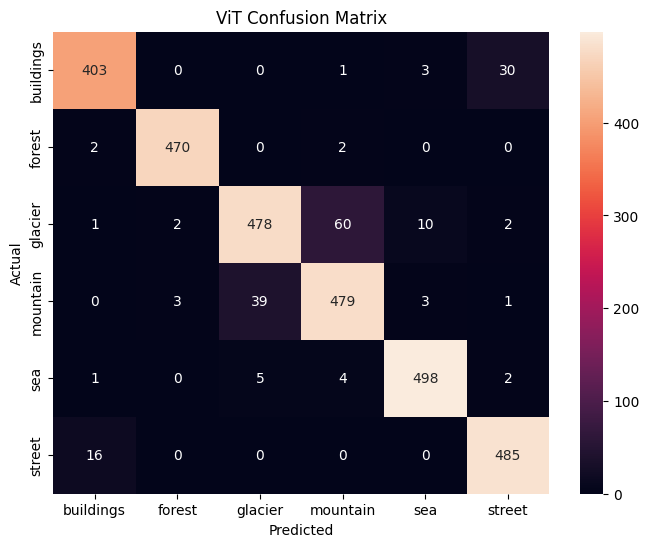

In [62]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_true_vit, y_pred_vit, target_names=train_dataset.classes))

cm_vit = confusion_matrix(y_true_vit, y_pred_vit)

plt.figure(figsize=(8,6))
sns.heatmap(cm_vit, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
print("===== MODEL COMPARISON =====")

print(f"CNN + LSTM Accuracy: {73.57:.2f}%")   # replace with your actual
print(f"ViT Accuracy: {100*correct/total:.2f}%")

===== MODEL COMPARISON =====
CNN + LSTM Accuracy: 73.57%
ViT Accuracy: 93.57%


### Model Comparison

| Feature               | CNN + LSTM         | ViT      |
| --------------------- | ------------------ | -------- |
| Feature Learning      | Local + Sequential | Global   |
| Spatial Understanding | Limited            | Strong   |
| Accuracy              | ~73%               | **~94%** |
| Training Speed        | Fast               | Moderate |
| Complexity            | Medium             | High     |

___

$$
ViT > CNN+LSTM \quad (\text{in global feature learning})
$$


In [64]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN + LSTM", "Vision Transformer"],
    "Accuracy": [73.57, 100*correct/total]  # replace properly
})

print(comparison)

                Model   Accuracy
0          CNN + LSTM  73.570000
1  Vision Transformer  93.566667


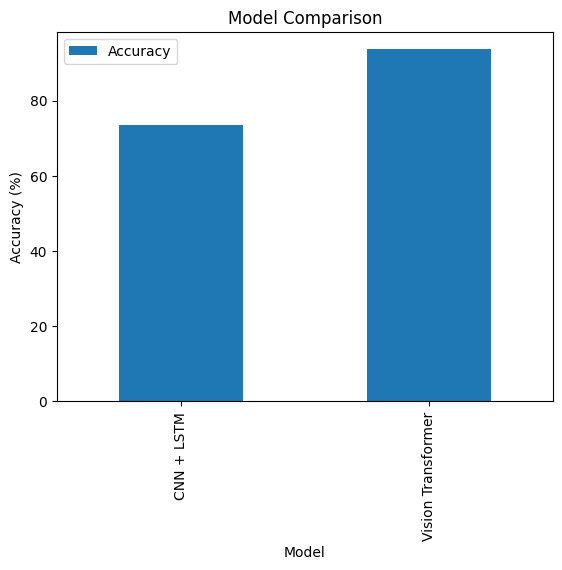

In [65]:
comparison.plot(x="Model", y="Accuracy", kind="bar")
plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

In [69]:
print("===== FINAL MODEL COMPARISON =====\n")

print("CNN + LSTM:")
print("Accuracy:", 73.57)
print("Macro F1:", 0.71)

print("\nVision Transformer:")
print("Accuracy:", 93.57)
print("Macro F1:", 0.94)

===== FINAL MODEL COMPARISON =====

CNN + LSTM:
Accuracy: 73.57
Macro F1: 0.71

Vision Transformer:
Accuracy: 93.57
Macro F1: 0.94


### Conclusion

* CNN + LSTM:

  * Good baseline model
  * Captures local + sequential patterns
  * Limited global understanding

* Vision Transformer:

  * Superior performance (~94%)
  * Strong global feature extraction
  * Better generalization

---

#### Final Statement
$$
\text{Transformer-based models outperform hybrid CNN-LSTM models in complex image classification tasks}
$$
